In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
data_path = '/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/MY_LSST_KN_TEST'
head = data_path + 'MY_LSST_KN_TEST_HEAD.FITS'
phot = data_path + 'MY_LSST_KN_TEST_PHOT.FITS'

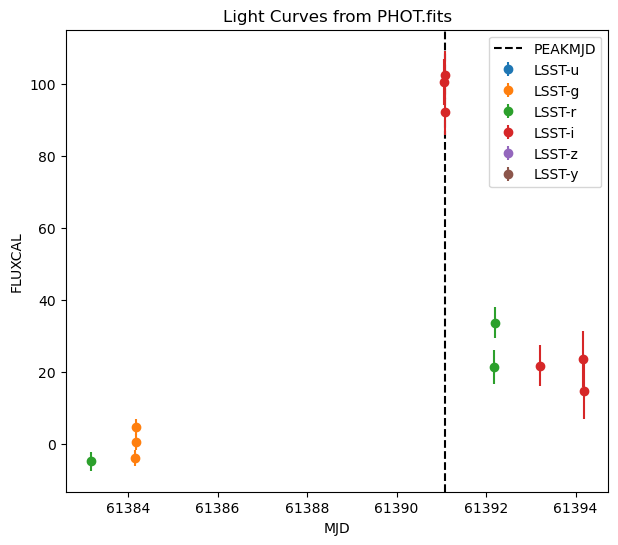

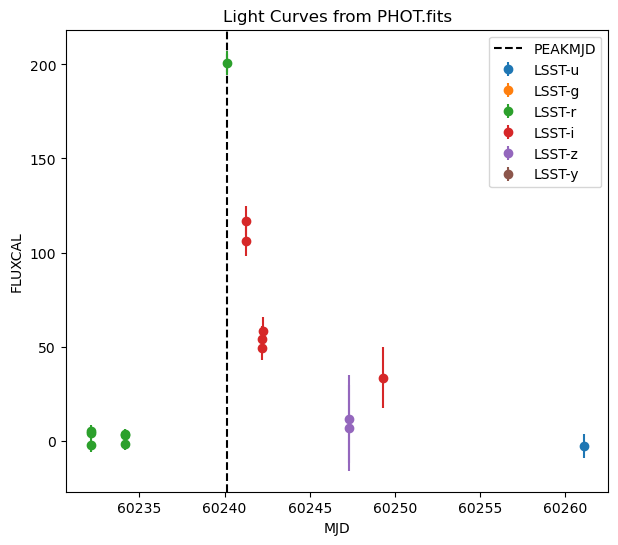

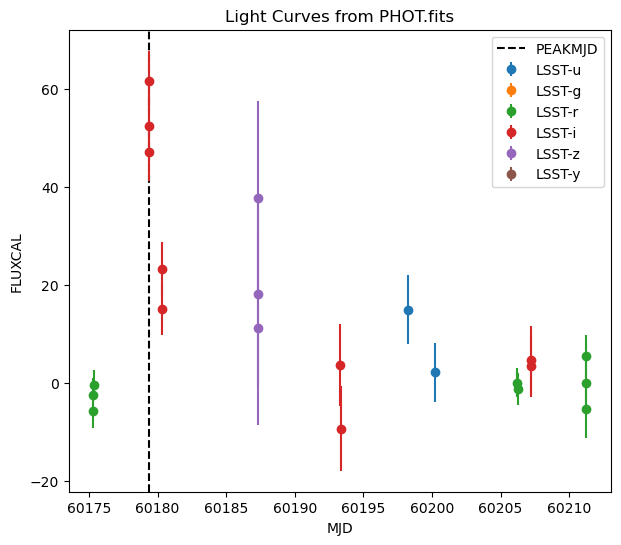

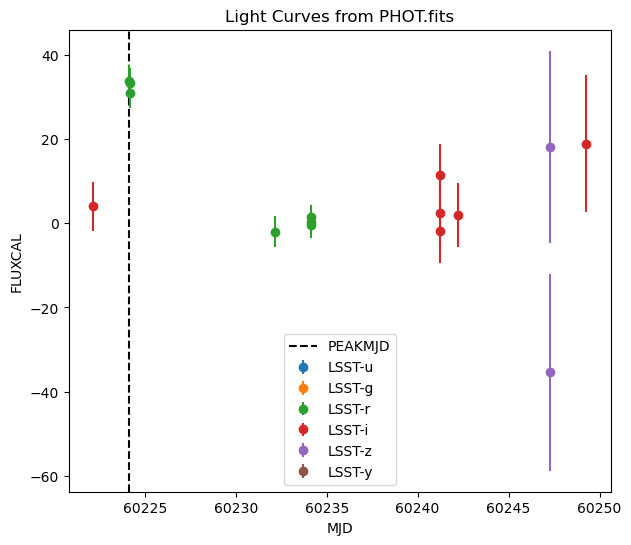

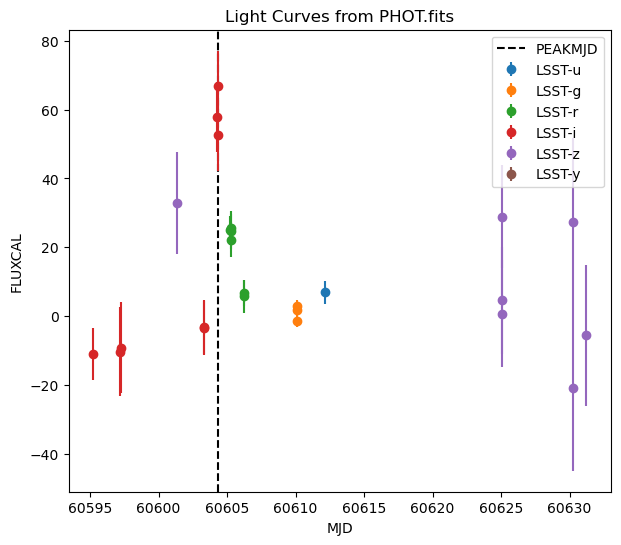

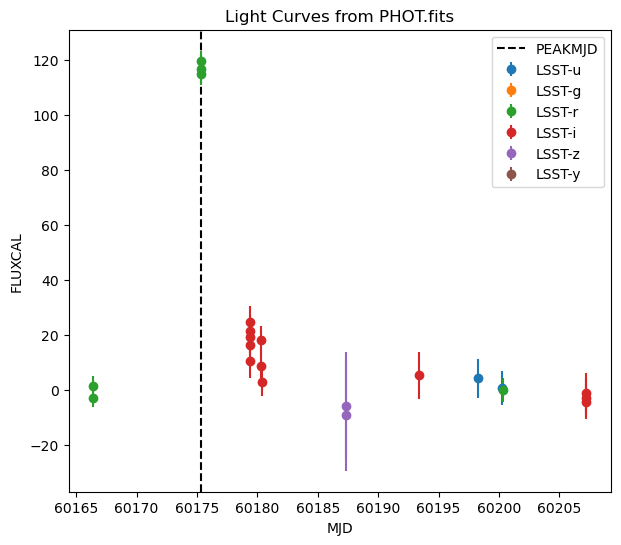

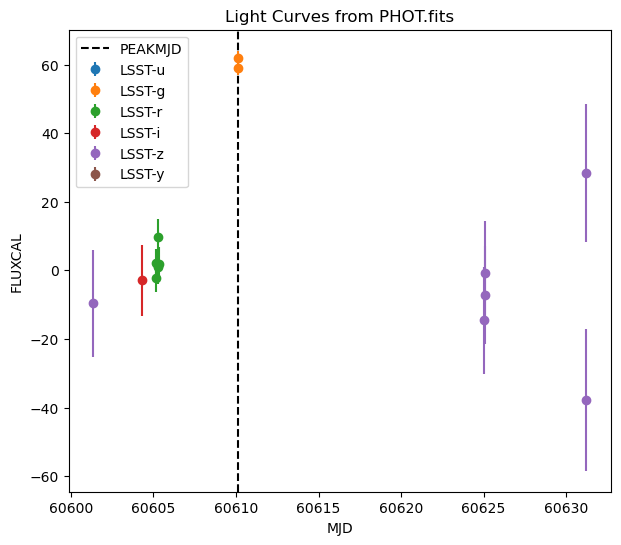

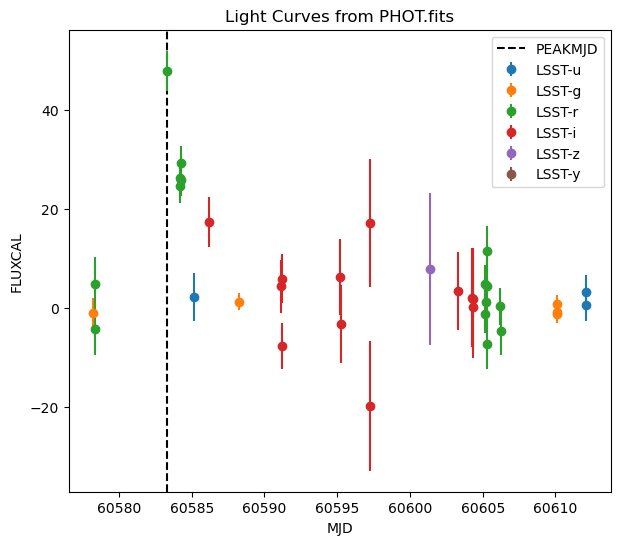

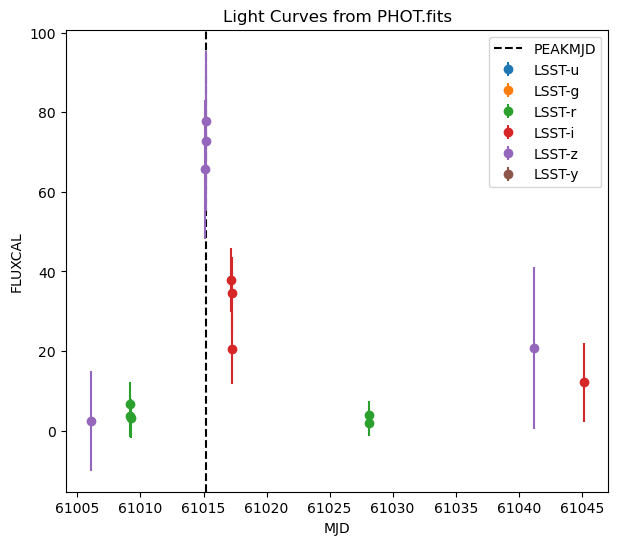

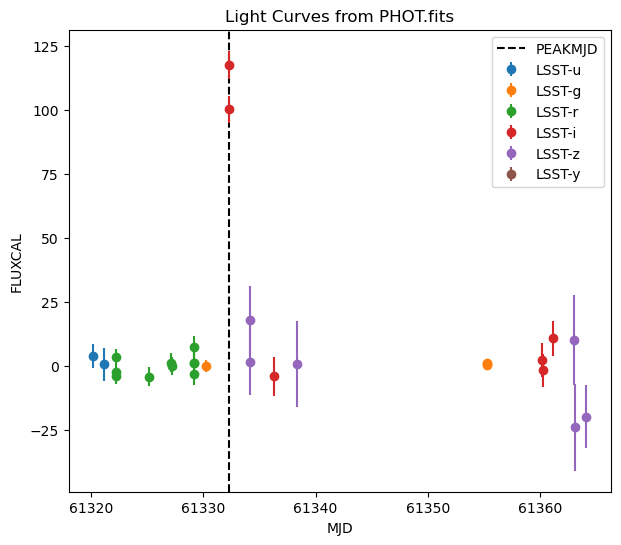

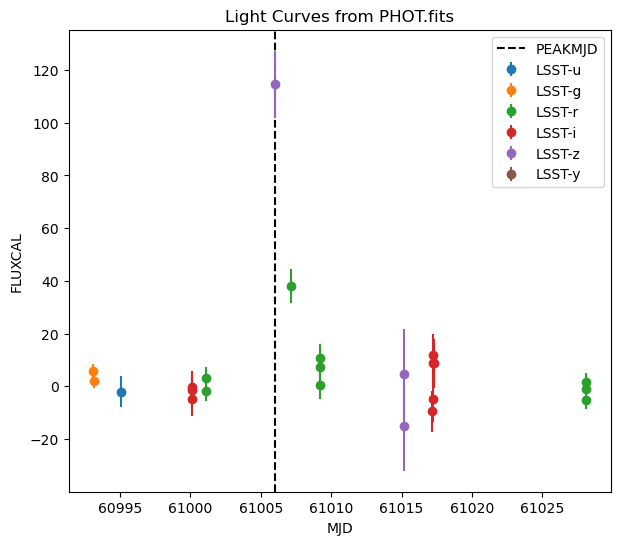

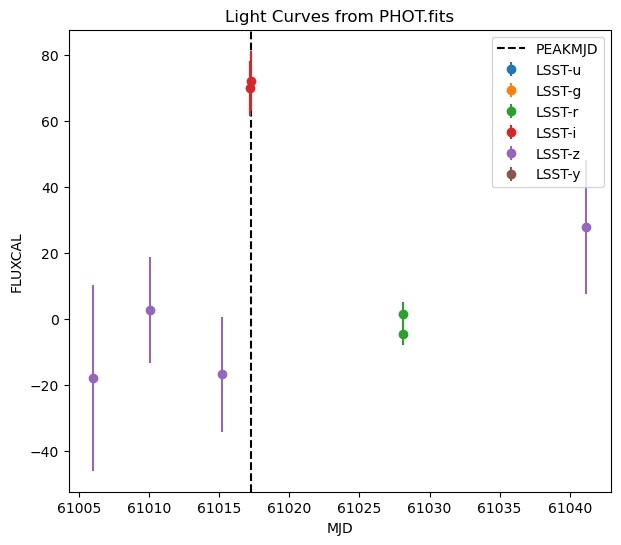

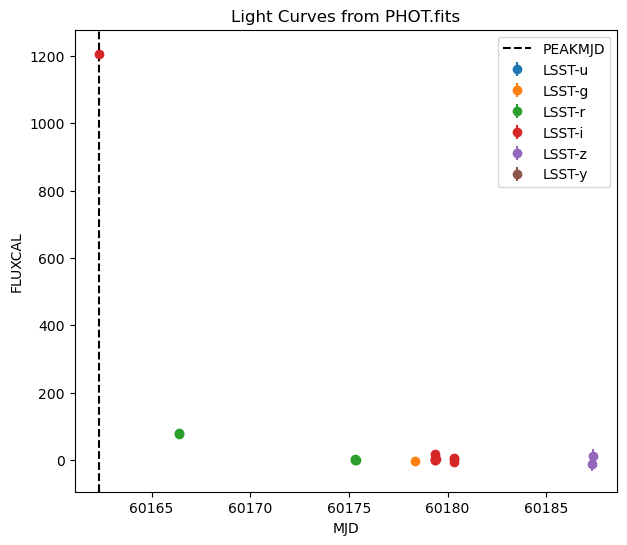

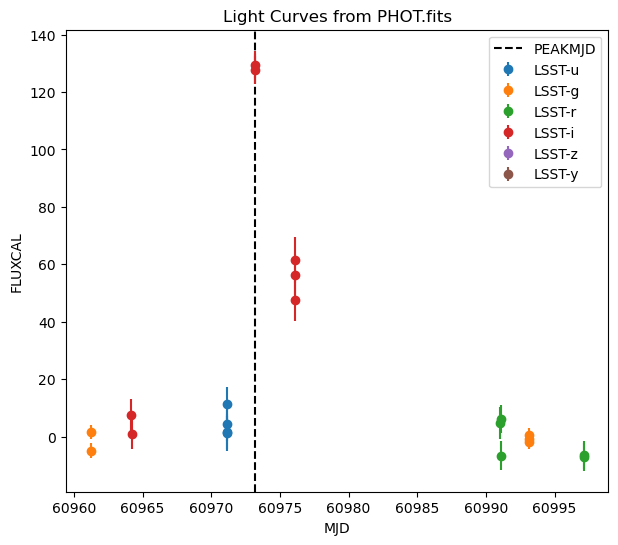

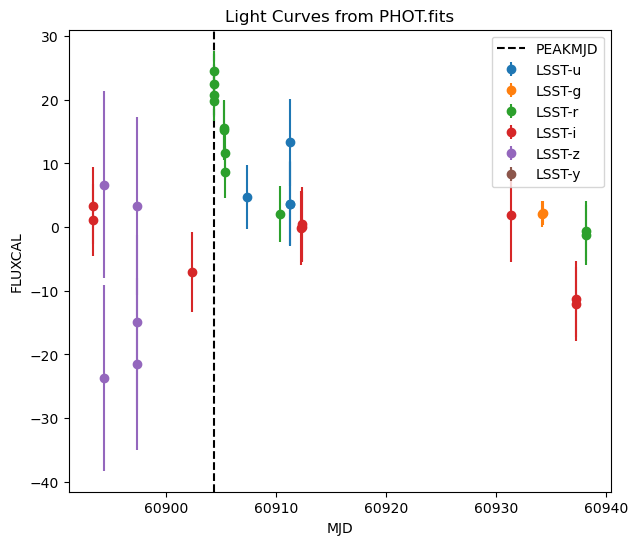

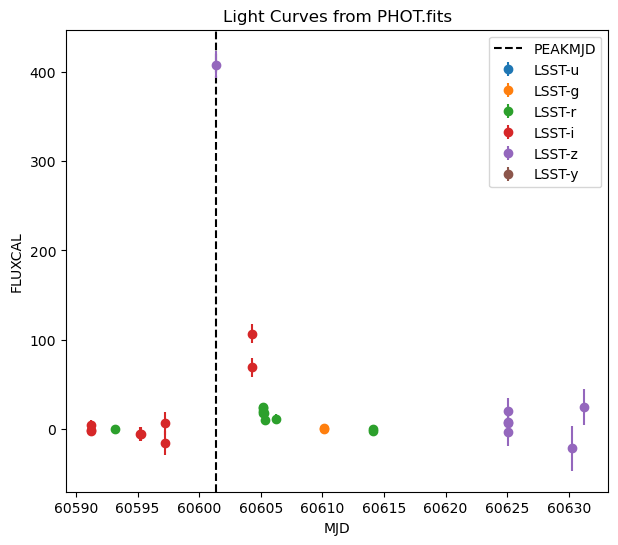

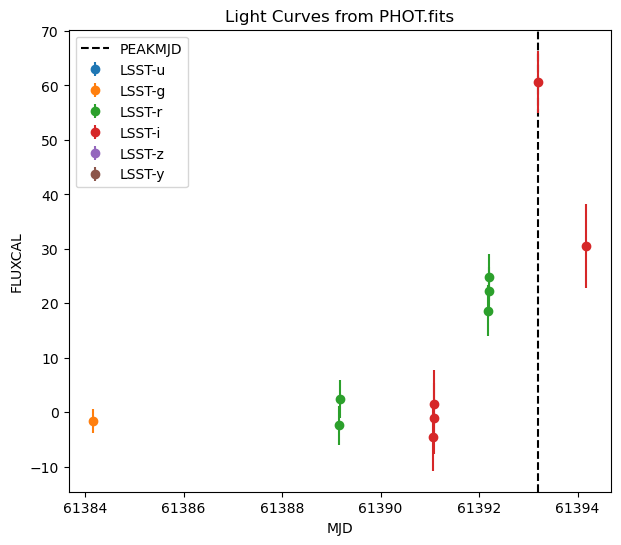

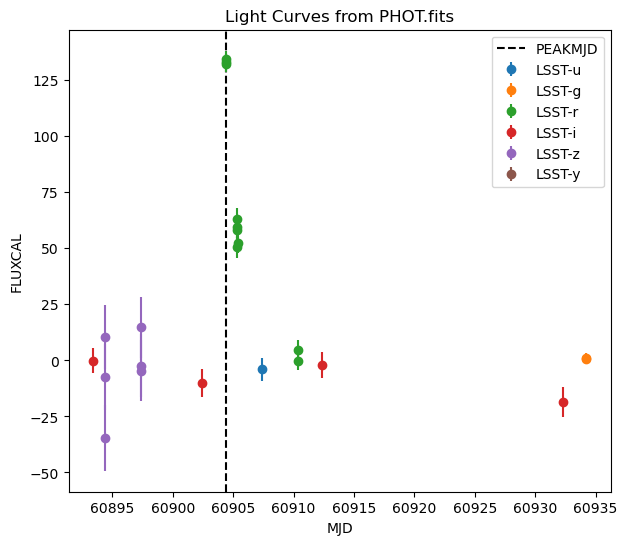

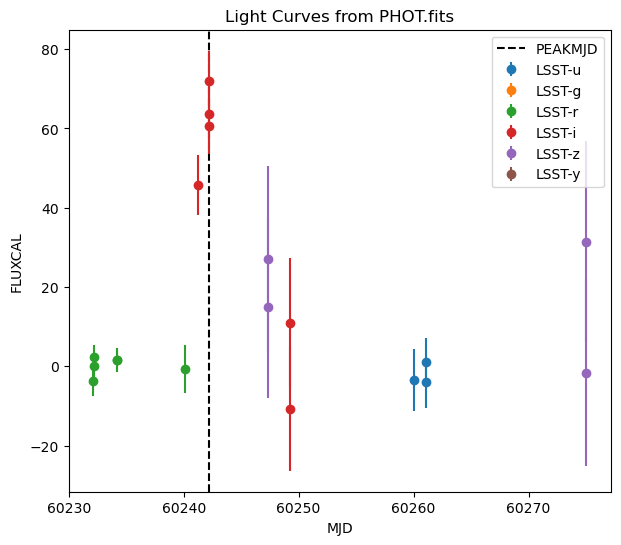

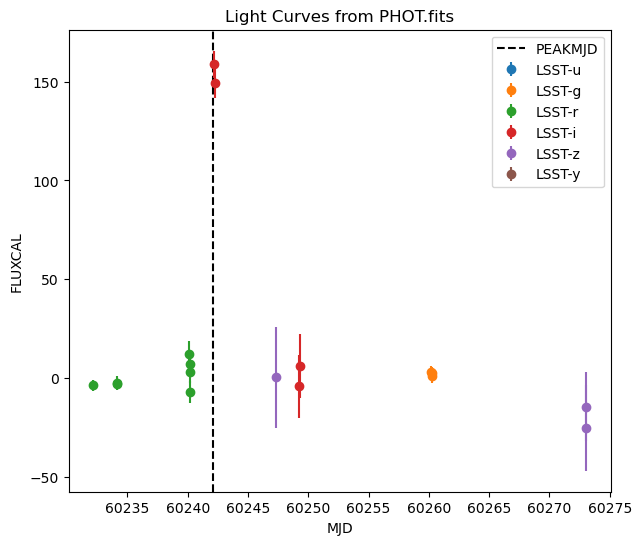

In [3]:
# 打开PHOT.fits文件
phot_hdul = fits.open(phot)
phot_data = phot_hdul[1].data

# 打开HEAD.fits文件，获取每个源的光变曲线索引分界
head_hdul = fits.open(head)
head_data = head_hdul[1].data
start_indices = head_data['PTROBS_MIN']
end_indices = head_data['PTROBS_MAX']

# 绘制每个源的光变曲线
bands = ['LSST-u','LSST-g','LSST-r','LSST-i','LSST-z','LSST-y']
for i, (start, end) in enumerate(zip(start_indices, end_indices)):
    if i >=20:
        break
    plt.figure(figsize=(7, 6))
    peakmjd = head_data['PEAKMJD'][i]
    plt.axvline(x=peakmjd, color='k', linestyle='--', label='PEAKMJD')
    source_data = phot_data[start-1:end]  # FITS索引通常从1开始
    mjd = source_data['MJD']
    flux = source_data['FLUXCAL']
    err = source_data['FLUXCALERR']
    for band in bands:
        band_mask = source_data['BAND'] == band
        plt.errorbar(mjd[band_mask], flux[band_mask], yerr=err[band_mask], fmt='o', label=band)
    # plt.errorbar(mjd, flux, yerr=err, fmt='o', label=f'Source {i+1}')
        plt.xlabel('MJD')
        plt.ylabel('FLUXCAL')
        plt.title('Light Curves from PHOT.fits')
        plt.legend()
        plt.savefig(f'./SIM/sim_lc/light_curve_source_{i+1}.png')
# plt.show()